# 03 — Exploratory Data Analysis (EDA)
## Financial Fraud Detection Project

---

### 1. Project & EDA Objective

**Exploratory Data Analysis (EDA)** is the process of systematically examining the cleaned dataset to discover patterns, relationships, and anomalies that may be associated with fraudulent transactions. In the context of fraud detection, EDA is critical because it helps us understand *which dimensions of the data* show observable differences between fraudulent and non-fraudulent transactions — providing the analytical foundation for later feature engineering and model development.

#### Questions This Notebook Answers

- What is the distribution of the target variable (`Fraud_Label`) in this synthetic dataset?
- Which transaction types, device types, locations, merchant categories, and card types show higher or lower observed fraud rates?
- How do numerical features (transaction amount, account balance, card age, daily transaction count) differ between fraud and non-fraud transactions?
- Does previous fraudulent activity appear to be associated with current fraud?
- Are there time-based patterns in observed fraud rates?
- What are the key correlations among numerical features?

#### Scope & Limitations

This notebook is **descriptive and exploratory only**. All findings represent observed associations in this synthetic dataset and should not be interpreted as causal relationships.

> **[!] No machine-learning model is trained, evaluated, or selected in this notebook.**
>
> This notebook does **NOT** perform: feature engineering, encoding, scaling, SMOTE, undersampling, train/test splitting, model training, model evaluation, model selection, or dashboard development.

**Input:** `data/processed/cleaned_fraud_dataset.csv` (output of Notebook 02)  
**Output:** Analytical findings and visualizations — no data files are saved.

---
### 2. Imports & Plotting Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.width", 120)

# Professional plotting configuration
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 100,
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 11,
})

print("Libraries imported and plotting configuration set.")

Libraries imported and plotting configuration set.


---
### 3. Robust Project Path Setup

In [2]:
def find_project_root(marker_files=("requirements.txt", "README.md", ".gitignore"), max_levels=5):
    """
    Walk upward from the current working directory to locate the project root.
    The root is identified by the presence of one of the marker files.
    """
    current = Path.cwd().resolve()
    for _ in range(max_levels):
        if any((current / m).exists() for m in marker_files):
            return current
        parent = current.parent
        if parent == current:
            break
        current = parent
    raise FileNotFoundError(
        "Could not locate project root. Ensure you run this notebook "
        "from within the project directory tree."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_fraud_dataset.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found at: {DATA_PATH}\n"
        "Please ensure Notebook 02 (data cleaning) has been executed first, "
        "producing 'cleaned_fraud_dataset.csv' inside data/processed/."
    )

print(f"Project root  : {PROJECT_ROOT}")
print(f"Dataset path  : {DATA_PATH}")

Project root  : C:\Users\sarva\Desktop\financial-fraud-detection
Dataset path  : C:\Users\sarva\Desktop\financial-fraud-detection\data\processed\cleaned_fraud_dataset.csv


---
### 4. Load Cleaned Dataset

In [3]:
df = pd.read_csv(DATA_PATH)

# Verify expected columns
EXPECTED_COLS = [
    "Transaction_ID", "User_ID", "Transaction_Amount", "Transaction_Type",
    "Date", "Account_Balance", "Device_Type", "Location",
    "Merchant_Category", "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count", "Card_Type", "Card_Age", "Fraud_Label"
]

missing_cols = [c for c in EXPECTED_COLS if c not in df.columns]
if missing_cols:
    print(f"[!] WARNING: Expected columns not found: {missing_cols}")
    print(f"   Available columns: {df.columns.tolist()}")

# Verify target column
TARGET_COL = "Fraud_Label"
if TARGET_COL not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COL}' not found. "
        f"Available columns: {df.columns.tolist()}"
    )

print(f"\nDataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")


Dataset loaded successfully.
Shape: 50,000 rows × 14 columns

Columns: ['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Date', 'Account_Balance', 'Device_Type', 'Location', 'Merchant_Category', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Card_Type', 'Card_Age', 'Fraud_Label']


In [4]:
# First five rows
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14,93213.17,Laptop,Sydney,Travel,0,7,Amex,65,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07,75725.25,Mobile,New York,Clothing,0,13,Mastercard,186,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20,1588.96,Tablet,Mumbai,Restaurants,0,14,Visa,226,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07,76807.20,Tablet,New York,Clothing,0,8,Visa,76,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11,92354.66,Mobile,Mumbai,Electronics,1,14,Mastercard,140,1


In [5]:
# Parse Date column into datetime for time-based EDA (temporary — not saved)
if "Date" in df.columns:
    df["_Date_parsed"] = pd.to_datetime(df["Date"], errors="coerce")
    n_parsed = df["_Date_parsed"].notna().sum()
    n_failed = df["_Date_parsed"].isna().sum()
    print(f"Date parsing: {n_parsed:,} valid, {n_failed:,} failed")
    if n_parsed > 0:
        print(f"Date range: {df['_Date_parsed'].min()} to {df['_Date_parsed'].max()}")
else:
    print("No 'Date' column found — time-based analysis will be skipped.")

Date parsing: 50,000 valid, 0 failed
Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


---
### 5. EDA Dataset Overview

A brief overview of the cleaned dataset. Detailed data understanding and quality checks were performed in **Notebook 01**; this section confirms the dataset structure for EDA.

In [6]:
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTarget column: {TARGET_COL}")

# Identify column types (excluding temporary columns)
analysis_cols = [c for c in df.columns if not c.startswith("_")]
numerical_cols = df[analysis_cols].select_dtypes(include="number").columns.tolist()
categorical_cols = df[analysis_cols].select_dtypes(include="object").columns.tolist()

print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Dataset shape: 50,000 rows × 15 columns

Target column: Fraud_Label

Numerical columns (6): ['Transaction_Amount', 'Account_Balance', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Card_Age', 'Fraud_Label']
Categorical columns (8): ['Transaction_ID', 'User_ID', 'Transaction_Type', 'Date', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type']


C:\Users\sarva\AppData\Local\Temp\ipykernel_34468\1228030310.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df[analysis_cols].select_dtypes(include="object").columns.tolist()


---
### 6. Target Distribution

In [7]:
# Calculate target distribution dynamically
total_transactions = len(df)
fraud_transactions = df[TARGET_COL].sum()
non_fraud_transactions = total_transactions - fraud_transactions
fraud_percentage = (fraud_transactions / total_transactions) * 100
non_fraud_percentage = (non_fraud_transactions / total_transactions) * 100

print("=" * 50)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 50)
print(f"Total transactions     : {total_transactions:,}")
print(f"Non-fraud (0)          : {non_fraud_transactions:,} ({non_fraud_percentage:.2f}%)")
print(f"Fraud (1)              : {fraud_transactions:,} ({fraud_percentage:.2f}%)")
print(f"Fraud-to-Non-Fraud ratio: 1 : {non_fraud_transactions / max(fraud_transactions, 1):.2f}")

# Percentage table
target_summary = pd.DataFrame({
    "Label": ["Non-Fraud (0)", "Fraud (1)"],
    "Count": [non_fraud_transactions, fraud_transactions],
    "Percentage (%)": [non_fraud_percentage, fraud_percentage]
}).set_index("Label")

display(target_summary)

TARGET VARIABLE DISTRIBUTION
Total transactions     : 50,000
Non-fraud (0)          : 33,933 (67.87%)
Fraud (1)              : 16,067 (32.13%)
Fraud-to-Non-Fraud ratio: 1 : 2.11


,Count,Percentage (%)
Label,,
Non-Fraud (0),33933,67.87
Fraud (1),16067,32.13


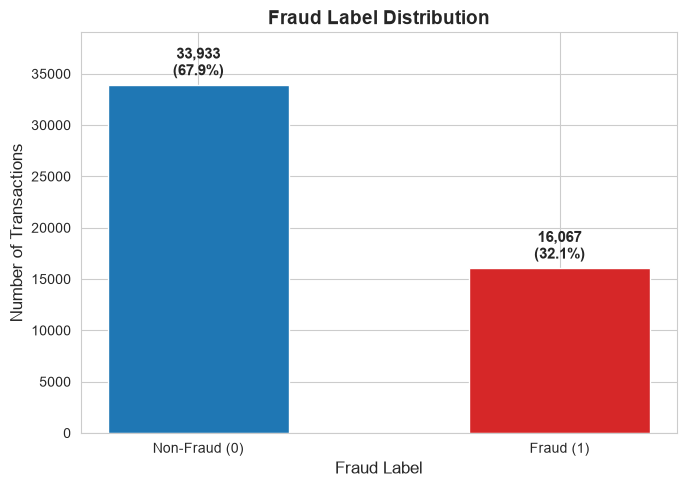


[!] IMPORTANT: The observed fraud proportion (~32.1%) reflects this synthetic dataset 
and should NOT be interpreted as a real-world fraud prevalence.
Real-world fraud rates are typically well below 1%.


In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = df[TARGET_COL].value_counts().sort_index()
bars = ax.bar(
    ["Non-Fraud (0)", "Fraud (1)"],
    counts.values,
    color=[sns.color_palette()[0], sns.color_palette()[3]],
    edgecolor="white",
    width=0.5
)

# Annotate with count and percentage
for bar, count in zip(bars, counts.values):
    pct = count / total_transactions * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + total_transactions * 0.01,
        f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Fraud Label Distribution")
ax.set_xlabel("Fraud Label")
ax.set_ylabel("Number of Transactions")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

print("\n[!] IMPORTANT: The observed fraud proportion (~{:.1f}%) reflects this synthetic dataset ".format(fraud_percentage))
print("and should NOT be interpreted as a real-world fraud prevalence.")
print("Real-world fraud rates are typically well below 1%.")

---
### 7. Transaction Amount Analysis

In [9]:
if "Transaction_Amount" in df.columns:
    # Summary statistics by fraud label
    amount_stats = df.groupby(TARGET_COL)["Transaction_Amount"].describe()
    amount_stats["median"] = df.groupby(TARGET_COL)["Transaction_Amount"].median()
    print("Transaction Amount — Summary Statistics by Fraud Label")
    display(amount_stats)
else:
    print("Column 'Transaction_Amount' not found — skipping this section.")

Transaction Amount — Summary Statistics by Fraud Label


,count,mean,std,min,25%,50%,75%,max,median
Fraud_Label,,,,,,,,,
0,33933.00,99.28,98.46,0.01,28.76,69.40,138.49,1174.14,69.40
1,16067.00,99.68,99.16,0.00,28.48,70.12,139.52,1005.32,70.12


C:\Users\sarva\AppData\Local\Temp\ipykernel_34468\658951721.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Non-Fraud (0)", "Fraud (1)"])


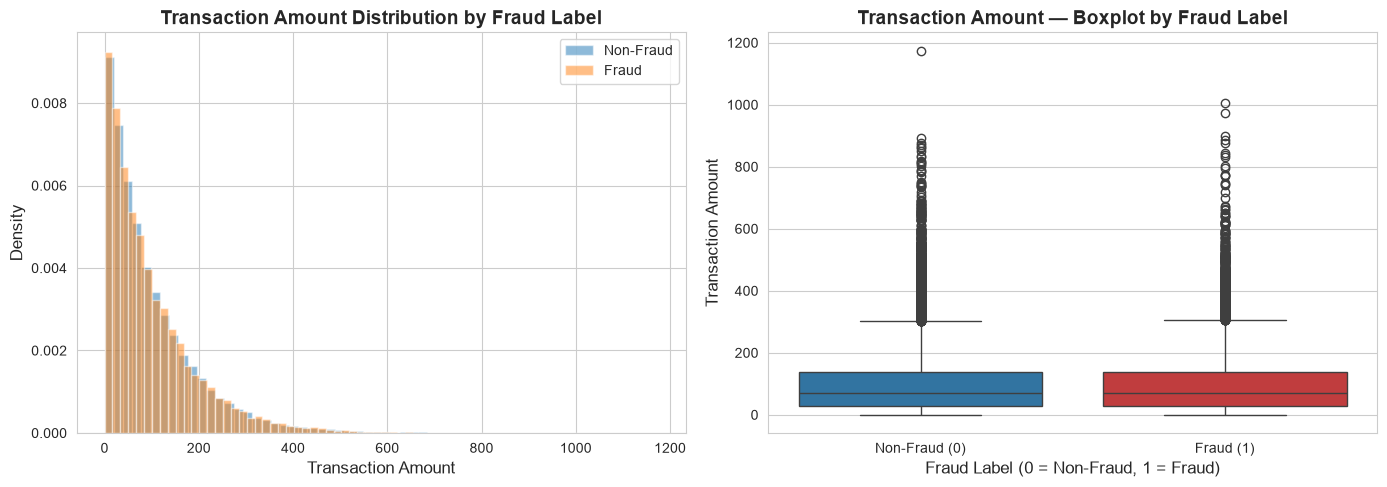


Transaction Amount skewness: 1.996
The distribution is highly skewed — showing log-scale view below.


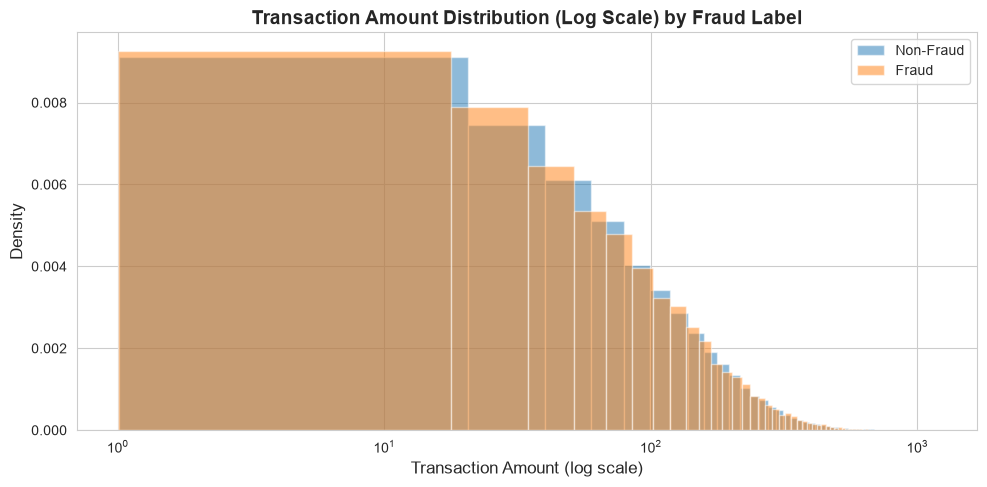

In [10]:
if "Transaction_Amount" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribution comparison (KDE)
    for label, name in [(0, "Non-Fraud"), (1, "Fraud")]:
        subset = df[df[TARGET_COL] == label]["Transaction_Amount"]
        axes[0].hist(subset, bins=60, alpha=0.5, label=name, density=True)
    axes[0].set_title("Transaction Amount Distribution by Fraud Label")
    axes[0].set_xlabel("Transaction Amount")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    # Boxplot comparison
    sns.boxplot(
        data=df, x=TARGET_COL, y="Transaction_Amount", ax=axes[1],
        hue=TARGET_COL, palette=[sns.color_palette()[0], sns.color_palette()[3]],
        legend=False
    )
    axes[1].set_title("Transaction Amount — Boxplot by Fraud Label")
    axes[1].set_xlabel("Fraud Label (0 = Non-Fraud, 1 = Fraud)")
    axes[1].set_ylabel("Transaction Amount")
    axes[1].set_xticklabels(["Non-Fraud (0)", "Fraud (1)"])

    plt.tight_layout()
    plt.show()

    # Check skewness
    skewness = df["Transaction_Amount"].skew()
    print(f"\nTransaction Amount skewness: {skewness:.3f}")
    if abs(skewness) > 1:
        print("The distribution is highly skewed — showing log-scale view below.")
        fig, ax = plt.subplots(figsize=(10, 5))
        for label, name in [(0, "Non-Fraud"), (1, "Fraud")]:
            subset = df[df[TARGET_COL] == label]["Transaction_Amount"]
            # Add small constant to handle zero values in log scale
            ax.hist(subset + 1, bins=60, alpha=0.5, label=name, density=True)
        ax.set_xscale("log")
        ax.set_title("Transaction Amount Distribution (Log Scale) by Fraud Label")
        ax.set_xlabel("Transaction Amount (log scale)")
        ax.set_ylabel("Density")
        ax.legend()
        plt.tight_layout()
        plt.show()

In [11]:
if "Transaction_Amount" in df.columns:
    mean_fraud = df.loc[df[TARGET_COL] == 1, "Transaction_Amount"].mean()
    mean_nonfraud = df.loc[df[TARGET_COL] == 0, "Transaction_Amount"].mean()
    median_fraud = df.loc[df[TARGET_COL] == 1, "Transaction_Amount"].median()
    median_nonfraud = df.loc[df[TARGET_COL] == 0, "Transaction_Amount"].median()

    print("Key Observations — Transaction Amount:")
    print(f"  Mean  (Non-Fraud): ${mean_nonfraud:,.2f}  |  Mean  (Fraud): ${mean_fraud:,.2f}")
    print(f"  Median(Non-Fraud): ${median_nonfraud:,.2f}  |  Median(Fraud): ${median_fraud:,.2f}")

    if mean_fraud > mean_nonfraud:
        print("\n  -> Fraudulent transactions appear to have a higher average amount.")
    elif mean_fraud < mean_nonfraud:
        print("\n  -> Fraudulent transactions appear to have a lower average amount.")
    else:
        print("\n  -> Average transaction amounts appear similar for fraud and non-fraud.")

    max_amount = df["Transaction_Amount"].max()
    print(f"\n  Maximum transaction amount: ${max_amount:,.2f}")
    print("  The distributions show overlap between fraud and non-fraud transactions.")

Key Observations — Transaction Amount:
  Mean  (Non-Fraud): $99.28  |  Mean  (Fraud): $99.68
  Median(Non-Fraud): $69.40  |  Median(Fraud): $70.12

  -> Fraudulent transactions appear to have a higher average amount.

  Maximum transaction amount: $1,174.14
  The distributions show overlap between fraud and non-fraud transactions.


---
### 8. Fraud by Transaction Type

In [12]:
if "Transaction_Type" in df.columns:
    # Calculate fraud rate by transaction type
    type_analysis = df.groupby("Transaction_Type").agg(
        Total_Count=(TARGET_COL, "count"),
        Fraud_Count=(TARGET_COL, "sum")
    ).reset_index()
    type_analysis["Non_Fraud_Count"] = type_analysis["Total_Count"] - type_analysis["Fraud_Count"]
    type_analysis["Fraud_Rate (%)"] = (
        type_analysis["Fraud_Count"] / type_analysis["Total_Count"].replace(0, np.nan) * 100
    ).round(2)
    type_analysis = type_analysis.sort_values("Fraud_Rate (%)", ascending=False)

    print("Fraud Analysis by Transaction Type")
    display(type_analysis.set_index("Transaction_Type"))
else:
    print("Column 'Transaction_Type' not found — skipping.")

Fraud Analysis by Transaction Type


,Total_Count,Fraud_Count,Non_Fraud_Count,Fraud_Rate (%)
Transaction_Type,,,,
ATM Withdrawal,12453,4046,8407,32.49
Online,12546,4031,8515,32.13
Bank Transfer,12452,3995,8457,32.08
POS,12549,3995,8554,31.84


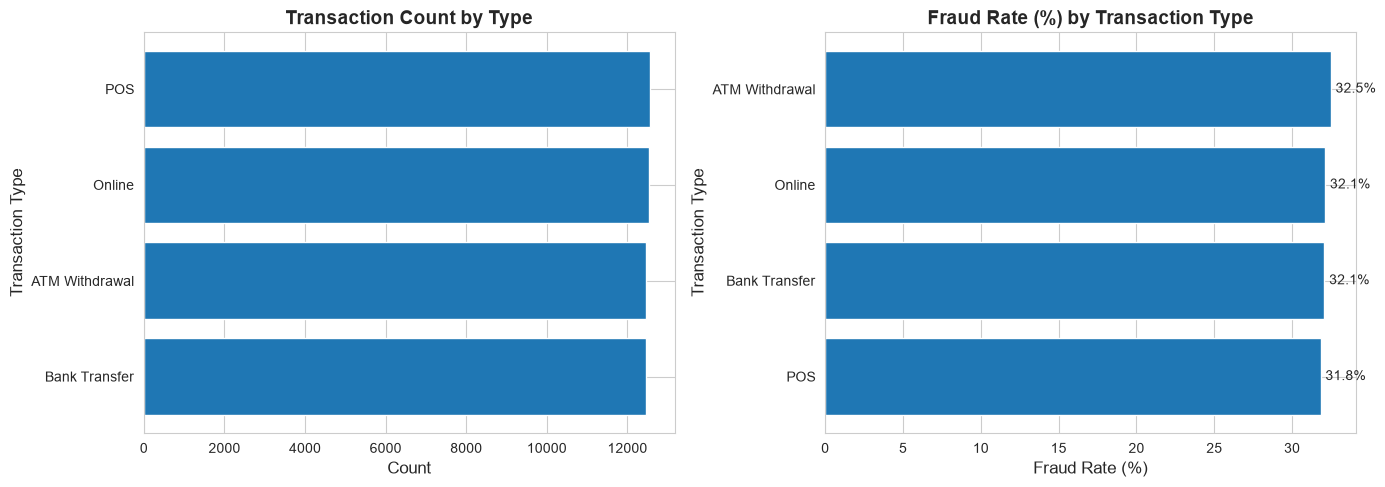


Highest observed fraud rate: ATM Withdrawal (32.5%)
Lowest observed fraud rate:  POS (31.8%)


In [13]:
if "Transaction_Type" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Transaction count by type
    order = type_analysis.sort_values("Total_Count", ascending=True)["Transaction_Type"]
    axes[0].barh(order, type_analysis.set_index("Transaction_Type").loc[order, "Total_Count"])
    axes[0].set_title("Transaction Count by Type")
    axes[0].set_xlabel("Count")
    axes[0].set_ylabel("Transaction Type")

    # Fraud rate by type (most informative)
    rate_order = type_analysis.sort_values("Fraud_Rate (%)", ascending=True)
    bars = axes[1].barh(
        rate_order["Transaction_Type"],
        rate_order["Fraud_Rate (%)"]
    )
    axes[1].set_title("Fraud Rate (%) by Transaction Type")
    axes[1].set_xlabel("Fraud Rate (%)")
    axes[1].set_ylabel("Transaction Type")

    # Annotate fraud rate bars
    for bar, rate in zip(bars, rate_order["Fraud_Rate (%)"]):
        axes[1].text(
            bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{rate:.1f}%", va="center", fontsize=10
        )

    plt.tight_layout()
    plt.show()

    # Interpretation
    highest_type = type_analysis.iloc[0]
    lowest_type = type_analysis.iloc[-1]
    print(f"\nHighest observed fraud rate: {highest_type['Transaction_Type']} ({highest_type['Fraud_Rate (%)']:.1f}%)")
    print(f"Lowest observed fraud rate:  {lowest_type['Transaction_Type']} ({lowest_type['Fraud_Rate (%)']:.1f}%)")

---
### 9. Fraud by Device Type

Fraud Analysis by Device Type


,Total_Count,Fraud_Count,Fraud_Rate (%)
Device_Type,,,
Tablet,16779,5464,32.56
Laptop,16581,5298,31.95
Mobile,16640,5305,31.88


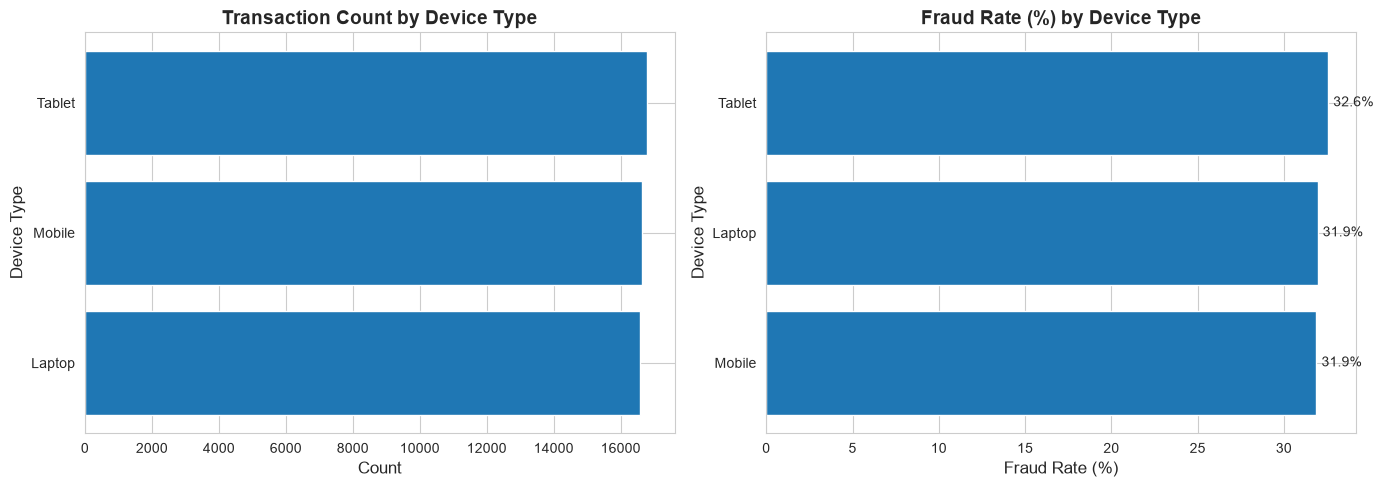


Highest observed fraud rate: Tablet (32.6%)
Lowest observed fraud rate:  Mobile (31.9%)

Note: The device type does not necessarily cause fraud; these are observed associations.


In [14]:
if "Device_Type" in df.columns:
    device_analysis = df.groupby("Device_Type").agg(
        Total_Count=(TARGET_COL, "count"),
        Fraud_Count=(TARGET_COL, "sum")
    ).reset_index()
    device_analysis["Fraud_Rate (%)"] = (
        device_analysis["Fraud_Count"] / device_analysis["Total_Count"].replace(0, np.nan) * 100
    ).round(2)
    device_analysis = device_analysis.sort_values("Fraud_Rate (%)", ascending=False)

    print("Fraud Analysis by Device Type")
    display(device_analysis.set_index("Device_Type"))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Transaction distribution by device
    dev_order = device_analysis.sort_values("Total_Count", ascending=True)["Device_Type"]
    axes[0].barh(dev_order, device_analysis.set_index("Device_Type").loc[dev_order, "Total_Count"])
    axes[0].set_title("Transaction Count by Device Type")
    axes[0].set_xlabel("Count")
    axes[0].set_ylabel("Device Type")

    # Fraud rate by device
    rate_order = device_analysis.sort_values("Fraud_Rate (%)", ascending=True)
    bars = axes[1].barh(rate_order["Device_Type"], rate_order["Fraud_Rate (%)"])
    axes[1].set_title("Fraud Rate (%) by Device Type")
    axes[1].set_xlabel("Fraud Rate (%)")
    axes[1].set_ylabel("Device Type")
    for bar, rate in zip(bars, rate_order["Fraud_Rate (%)"]):
        axes[1].text(
            bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{rate:.1f}%", va="center", fontsize=10
        )

    plt.tight_layout()
    plt.show()

    highest_dev = device_analysis.iloc[0]
    lowest_dev = device_analysis.iloc[-1]
    print(f"\nHighest observed fraud rate: {highest_dev['Device_Type']} ({highest_dev['Fraud_Rate (%)']:.1f}%)")
    print(f"Lowest observed fraud rate:  {lowest_dev['Device_Type']} ({lowest_dev['Fraud_Rate (%)']:.1f}%)")
    print("\nNote: The device type does not necessarily cause fraud; these are observed associations.")
else:
    print("Column 'Device_Type' not found — skipping.")

---
### 10. Fraud by Location

Number of unique locations: 5

Fraud Analysis by Location


,Total_Count,Fraud_Count,Fraud_Rate (%)
Location,,,
New York,9915,3221,32.49
Tokyo,10208,3315,32.47
Sydney,9938,3194,32.14
London,9945,3181,31.99
Mumbai,9994,3156,31.58


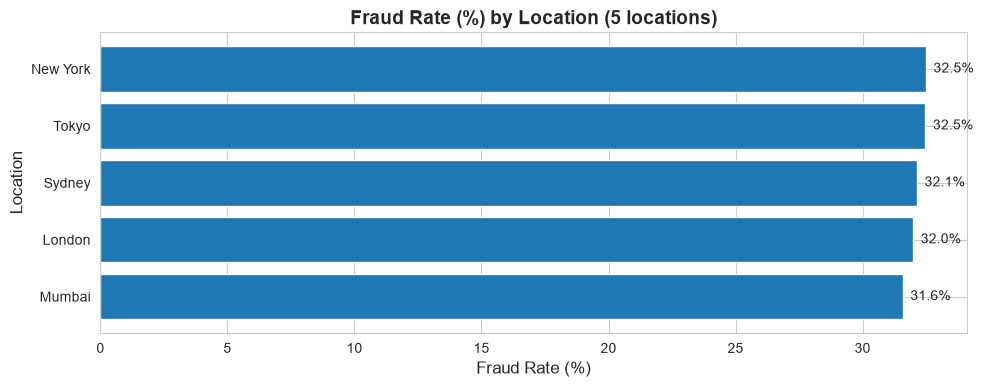


Highest observed fraud rate: New York (32.5%)
Lowest observed fraud rate:  Mumbai (31.6%)


In [15]:
if "Location" in df.columns:
    n_locations = df["Location"].nunique()
    print(f"Number of unique locations: {n_locations}")

    location_analysis = df.groupby("Location").agg(
        Total_Count=(TARGET_COL, "count"),
        Fraud_Count=(TARGET_COL, "sum")
    ).reset_index()
    location_analysis["Fraud_Rate (%)"] = (
        location_analysis["Fraud_Count"] / location_analysis["Total_Count"].replace(0, np.nan) * 100
    ).round(2)
    location_analysis = location_analysis.sort_values("Fraud_Rate (%)", ascending=False)

    print("\nFraud Analysis by Location")
    display(location_analysis.set_index("Location"))

    # Horizontal bar chart sorted by fraud rate
    fig, ax = plt.subplots(figsize=(10, max(4, n_locations * 0.6)))
    rate_sorted = location_analysis.sort_values("Fraud_Rate (%)", ascending=True)
    bars = ax.barh(rate_sorted["Location"], rate_sorted["Fraud_Rate (%)"])
    ax.set_title(f"Fraud Rate (%) by Location ({n_locations} locations)")
    ax.set_xlabel("Fraud Rate (%)")
    ax.set_ylabel("Location")
    for bar, rate in zip(bars, rate_sorted["Fraud_Rate (%)"]):
        ax.text(
            bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{rate:.1f}%", va="center", fontsize=10
        )
    plt.tight_layout()
    plt.show()

    highest_loc = location_analysis.iloc[0]
    lowest_loc = location_analysis.iloc[-1]
    print(f"\nHighest observed fraud rate: {highest_loc['Location']} ({highest_loc['Fraud_Rate (%)']:.1f}%)")
    print(f"Lowest observed fraud rate:  {lowest_loc['Location']} ({lowest_loc['Fraud_Rate (%)']:.1f}%)")
else:
    print("Column 'Location' not found — skipping.")

---
### 11. Fraud by Merchant Category

Fraud Analysis by Merchant Category


,Total_Count,Fraud_Count,Fraud_Rate (%)
Merchant_Category,,,
Restaurants,9976,3255,32.63
Travel,10015,3235,32.30
Groceries,10019,3217,32.11
Electronics,9957,3179,31.93
Clothing,10033,3181,31.71


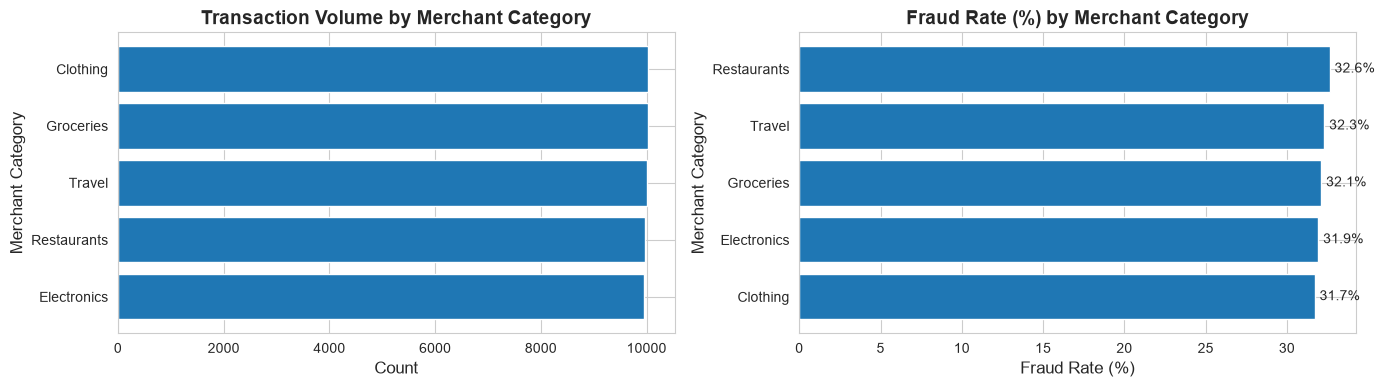


Highest observed fraud rate: Restaurants (32.6%)
Lowest observed fraud rate:  Clothing (31.7%)


In [16]:
if "Merchant_Category" in df.columns:
    merchant_analysis = df.groupby("Merchant_Category").agg(
        Total_Count=(TARGET_COL, "count"),
        Fraud_Count=(TARGET_COL, "sum")
    ).reset_index()
    merchant_analysis["Fraud_Rate (%)"] = (
        merchant_analysis["Fraud_Count"] / merchant_analysis["Total_Count"].replace(0, np.nan) * 100
    ).round(2)
    merchant_analysis = merchant_analysis.sort_values("Fraud_Rate (%)", ascending=False)

    print("Fraud Analysis by Merchant Category")
    display(merchant_analysis.set_index("Merchant_Category"))

    n_merchants = len(merchant_analysis)
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, n_merchants * 0.7)))

    # Transaction volume
    vol_sorted = merchant_analysis.sort_values("Total_Count", ascending=True)
    axes[0].barh(vol_sorted["Merchant_Category"], vol_sorted["Total_Count"])
    axes[0].set_title("Transaction Volume by Merchant Category")
    axes[0].set_xlabel("Count")
    axes[0].set_ylabel("Merchant Category")

    # Fraud rate
    rate_sorted = merchant_analysis.sort_values("Fraud_Rate (%)", ascending=True)
    bars = axes[1].barh(rate_sorted["Merchant_Category"], rate_sorted["Fraud_Rate (%)"])
    axes[1].set_title("Fraud Rate (%) by Merchant Category")
    axes[1].set_xlabel("Fraud Rate (%)")
    axes[1].set_ylabel("Merchant Category")
    for bar, rate in zip(bars, rate_sorted["Fraud_Rate (%)"]):
        axes[1].text(
            bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{rate:.1f}%", va="center", fontsize=10
        )

    plt.tight_layout()
    plt.show()

    highest_merch = merchant_analysis.iloc[0]
    lowest_merch = merchant_analysis.iloc[-1]
    print(f"\nHighest observed fraud rate: {highest_merch['Merchant_Category']} ({highest_merch['Fraud_Rate (%)']:.1f}%)")
    print(f"Lowest observed fraud rate:  {lowest_merch['Merchant_Category']} ({lowest_merch['Fraud_Rate (%)']:.1f}%)")
else:
    print("Column 'Merchant_Category' not found — skipping.")

---
### 12. Fraud by Card Type

Fraud Analysis by Card Type


,Total_Count,Fraud_Count,Fraud_Rate (%)
Card_Type,,,
Discover,12328,4006,32.50
Amex,12419,4021,32.38
Visa,12560,4002,31.86
Mastercard,12693,4038,31.81


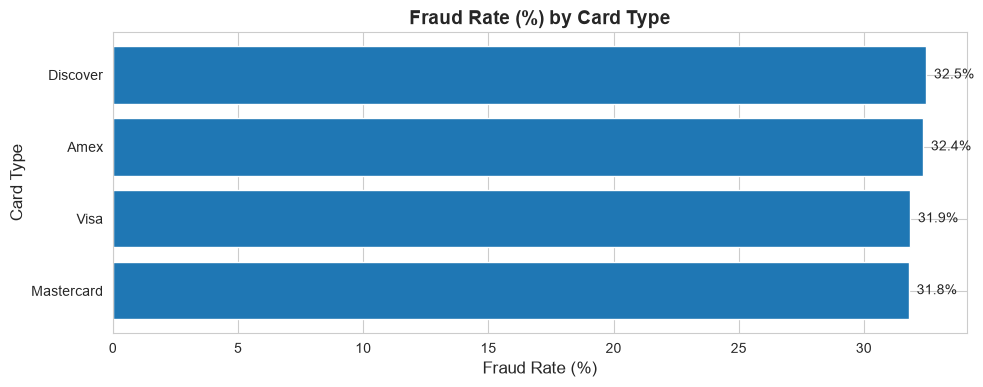


Highest observed fraud rate: Discover (32.5%)
Lowest observed fraud rate:  Mastercard (31.8%)

Note: Differences may reflect synthetic data generation patterns; interpret with caution.


In [17]:
if "Card_Type" in df.columns:
    card_analysis = df.groupby("Card_Type").agg(
        Total_Count=(TARGET_COL, "count"),
        Fraud_Count=(TARGET_COL, "sum")
    ).reset_index()
    card_analysis["Fraud_Rate (%)"] = (
        card_analysis["Fraud_Count"] / card_analysis["Total_Count"].replace(0, np.nan) * 100
    ).round(2)
    card_analysis = card_analysis.sort_values("Fraud_Rate (%)", ascending=False)

    print("Fraud Analysis by Card Type")
    display(card_analysis.set_index("Card_Type"))

    fig, ax = plt.subplots(figsize=(10, 4))
    rate_sorted = card_analysis.sort_values("Fraud_Rate (%)", ascending=True)
    bars = ax.barh(rate_sorted["Card_Type"], rate_sorted["Fraud_Rate (%)"])
    ax.set_title("Fraud Rate (%) by Card Type")
    ax.set_xlabel("Fraud Rate (%)")
    ax.set_ylabel("Card Type")
    for bar, rate in zip(bars, rate_sorted["Fraud_Rate (%)"]):
        ax.text(
            bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{rate:.1f}%", va="center", fontsize=10
        )
    plt.tight_layout()
    plt.show()

    highest_card = card_analysis.iloc[0]
    lowest_card = card_analysis.iloc[-1]
    print(f"\nHighest observed fraud rate: {highest_card['Card_Type']} ({highest_card['Fraud_Rate (%)']:.1f}%)")
    print(f"Lowest observed fraud rate:  {lowest_card['Card_Type']} ({lowest_card['Fraud_Rate (%)']:.1f}%)")
    print("\nNote: Differences may reflect synthetic data generation patterns; interpret with caution.")
else:
    print("Column 'Card_Type' not found — skipping.")

---
### 13. Previous Fraudulent Activity vs Fraud

Fraud Analysis by Previous Fraudulent Activity


,Total_Count,Fraud_Count,Non_Fraud_Count,Fraud_Rate (%)
Previous_Fraudulent_Activity,,,,
No (0),45080,14491,30589,32.15
Yes (1),4920,1576,3344,32.03


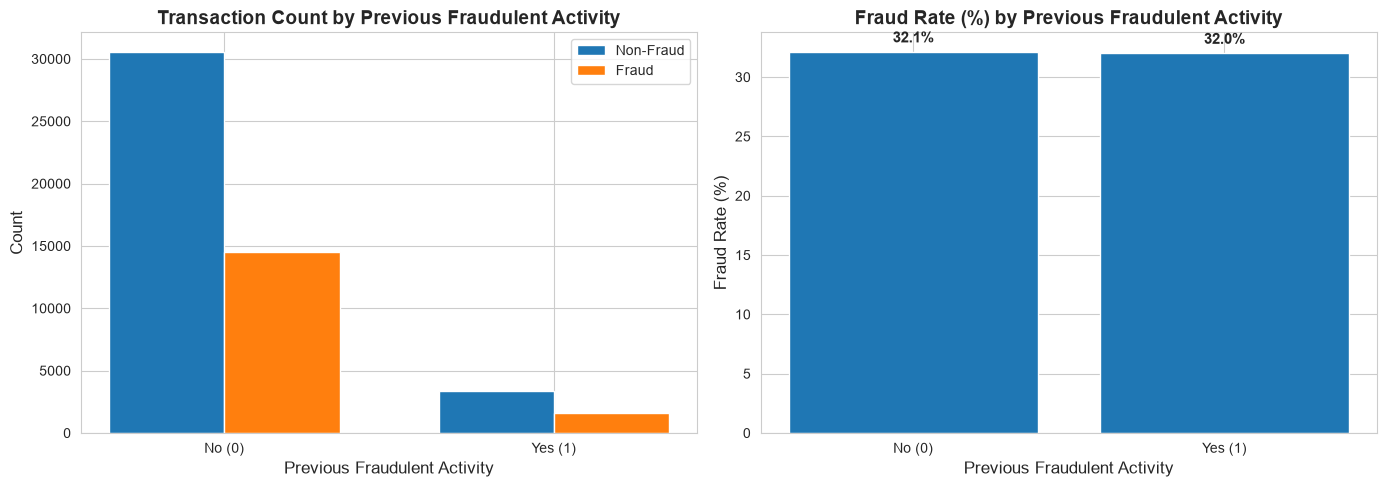


Fraud rate — No previous activity:  32.1%
Fraud rate — Yes previous activity: 32.0%

-> Transactions with previous fraudulent activity show a lower observed fraud rate.

This is an important potential behavioral signal, but should not be called a predictive feature yet.


In [18]:
if "Previous_Fraudulent_Activity" in df.columns:
    prev_fraud_analysis = df.groupby("Previous_Fraudulent_Activity").agg(
        Total_Count=(TARGET_COL, "count"),
        Fraud_Count=(TARGET_COL, "sum")
    ).reset_index()
    prev_fraud_analysis["Non_Fraud_Count"] = prev_fraud_analysis["Total_Count"] - prev_fraud_analysis["Fraud_Count"]
    prev_fraud_analysis["Fraud_Rate (%)"] = (
        prev_fraud_analysis["Fraud_Count"] / prev_fraud_analysis["Total_Count"].replace(0, np.nan) * 100
    ).round(2)

    # Rename for readability
    prev_fraud_analysis["Previous_Fraudulent_Activity"] = prev_fraud_analysis[
        "Previous_Fraudulent_Activity"
    ].map({0: "No (0)", 1: "Yes (1)"})

    print("Fraud Analysis by Previous Fraudulent Activity")
    display(prev_fraud_analysis.set_index("Previous_Fraudulent_Activity"))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Count comparison
    x = prev_fraud_analysis["Previous_Fraudulent_Activity"]
    width = 0.35
    x_pos = np.arange(len(x))
    axes[0].bar(x_pos - width/2, prev_fraud_analysis["Non_Fraud_Count"], width, label="Non-Fraud")
    axes[0].bar(x_pos + width/2, prev_fraud_analysis["Fraud_Count"], width, label="Fraud")
    axes[0].set_title("Transaction Count by Previous Fraudulent Activity")
    axes[0].set_xlabel("Previous Fraudulent Activity")
    axes[0].set_ylabel("Count")
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(x)
    axes[0].legend()

    # Fraud rate comparison
    bars = axes[1].bar(x, prev_fraud_analysis["Fraud_Rate (%)"])
    axes[1].set_title("Fraud Rate (%) by Previous Fraudulent Activity")
    axes[1].set_xlabel("Previous Fraudulent Activity")
    axes[1].set_ylabel("Fraud Rate (%)")
    for bar, rate in zip(bars, prev_fraud_analysis["Fraud_Rate (%)"]):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{rate:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

    # Interpretation
    rate_yes = prev_fraud_analysis.loc[
        prev_fraud_analysis["Previous_Fraudulent_Activity"] == "Yes (1)", "Fraud_Rate (%)"
    ].values
    rate_no = prev_fraud_analysis.loc[
        prev_fraud_analysis["Previous_Fraudulent_Activity"] == "No (0)", "Fraud_Rate (%)"
    ].values

    if len(rate_yes) > 0 and len(rate_no) > 0:
        print(f"\nFraud rate — No previous activity:  {rate_no[0]:.1f}%")
        print(f"Fraud rate — Yes previous activity: {rate_yes[0]:.1f}%")
        if rate_yes[0] > rate_no[0]:
            print("\n-> Transactions with previous fraudulent activity show a higher observed fraud rate.")
        elif rate_yes[0] < rate_no[0]:
            print("\n-> Transactions with previous fraudulent activity show a lower observed fraud rate.")
        else:
            print("\n-> Fraud rates appear similar regardless of previous fraudulent activity.")
    print("\nThis is an important potential behavioral signal, but should not be called a predictive feature yet.")
else:
    print("Column 'Previous_Fraudulent_Activity' not found — skipping.")

---
### 14. Daily Transaction Count vs Fraud

Daily Transaction Count — Summary Statistics by Fraud Label


,count,mean,std,min,25%,50%,75%,max,median
Fraud_Label,,,,,,,,,
0,33933.00,7.50,4.04,1.00,4.00,7.00,11.00,14.00,7.00
1,16067.00,7.44,4.04,1.00,4.00,7.00,11.00,14.00,7.00


C:\Users\sarva\AppData\Local\Temp\ipykernel_34468\289334795.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Non-Fraud (0)", "Fraud (1)"])


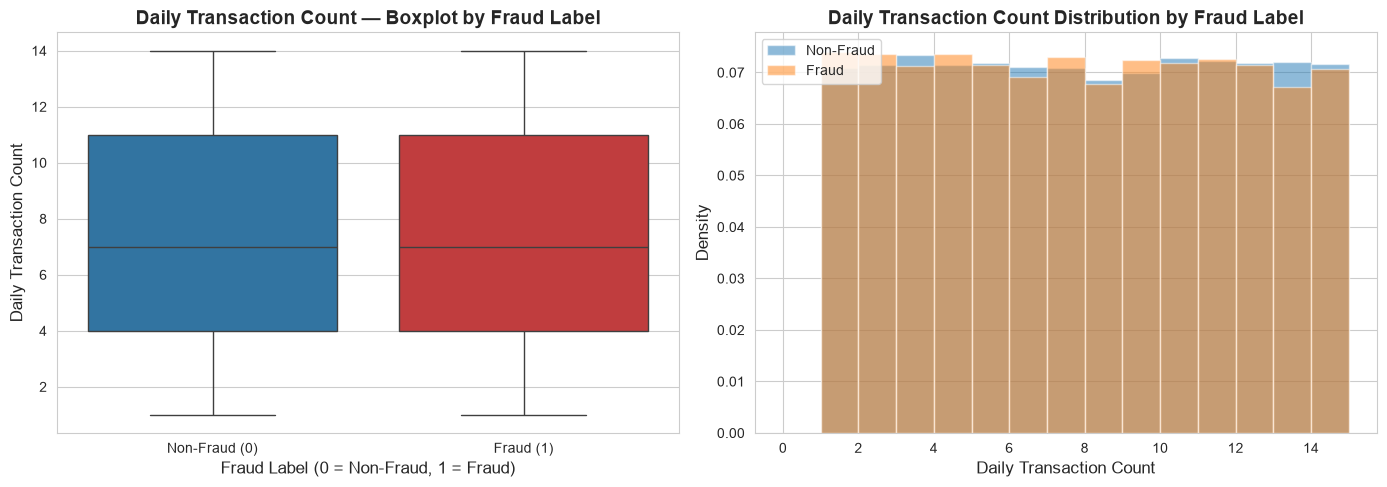


Mean daily transaction count — Non-Fraud: 7.50 | Fraud: 7.44
-> Fraudulent transactions appear associated with lower daily transaction counts.


In [19]:
if "Daily_Transaction_Count" in df.columns:
    # Summary statistics by fraud label
    dtc_stats = df.groupby(TARGET_COL)["Daily_Transaction_Count"].describe()
    dtc_stats["median"] = df.groupby(TARGET_COL)["Daily_Transaction_Count"].median()
    print("Daily Transaction Count — Summary Statistics by Fraud Label")
    display(dtc_stats)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot
    sns.boxplot(
        data=df, x=TARGET_COL, y="Daily_Transaction_Count", ax=axes[0],
        hue=TARGET_COL, palette=[sns.color_palette()[0], sns.color_palette()[3]],
        legend=False
    )
    axes[0].set_title("Daily Transaction Count — Boxplot by Fraud Label")
    axes[0].set_xlabel("Fraud Label (0 = Non-Fraud, 1 = Fraud)")
    axes[0].set_ylabel("Daily Transaction Count")
    axes[0].set_xticklabels(["Non-Fraud (0)", "Fraud (1)"])

    # Histogram comparison
    for label, name in [(0, "Non-Fraud"), (1, "Fraud")]:
        subset = df[df[TARGET_COL] == label]["Daily_Transaction_Count"]
        axes[1].hist(subset, bins=range(0, int(df["Daily_Transaction_Count"].max()) + 2),
                     alpha=0.5, label=name, density=True)
    axes[1].set_title("Daily Transaction Count Distribution by Fraud Label")
    axes[1].set_xlabel("Daily Transaction Count")
    axes[1].set_ylabel("Density")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    mean_fraud_dtc = df.loc[df[TARGET_COL] == 1, "Daily_Transaction_Count"].mean()
    mean_nonfraud_dtc = df.loc[df[TARGET_COL] == 0, "Daily_Transaction_Count"].mean()
    print(f"\nMean daily transaction count — Non-Fraud: {mean_nonfraud_dtc:.2f} | Fraud: {mean_fraud_dtc:.2f}")
    if mean_fraud_dtc > mean_nonfraud_dtc:
        print("-> Fraudulent transactions appear associated with higher daily transaction counts.")
    elif mean_fraud_dtc < mean_nonfraud_dtc:
        print("-> Fraudulent transactions appear associated with lower daily transaction counts.")
    else:
        print("-> Daily transaction counts appear similar for fraud and non-fraud.")
else:
    print("Column 'Daily_Transaction_Count' not found — skipping.")

---
### 15. Account Balance vs Fraud

Account Balance — Summary Statistics by Fraud Label


,count,mean,std,min,25%,50%,75%,max,median
Fraud_Label,,,,,,,,,
0,33933.00,50356.47,28734.00,500.48,25530.16,50370.35,75217.28,99998.31,50370.35
1,16067.00,50162.26,28816.71,503.94,24977.27,50415.02,74902.60,99997.79,50415.02


C:\Users\sarva\AppData\Local\Temp\ipykernel_34468\1519747649.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Non-Fraud (0)", "Fraud (1)"])


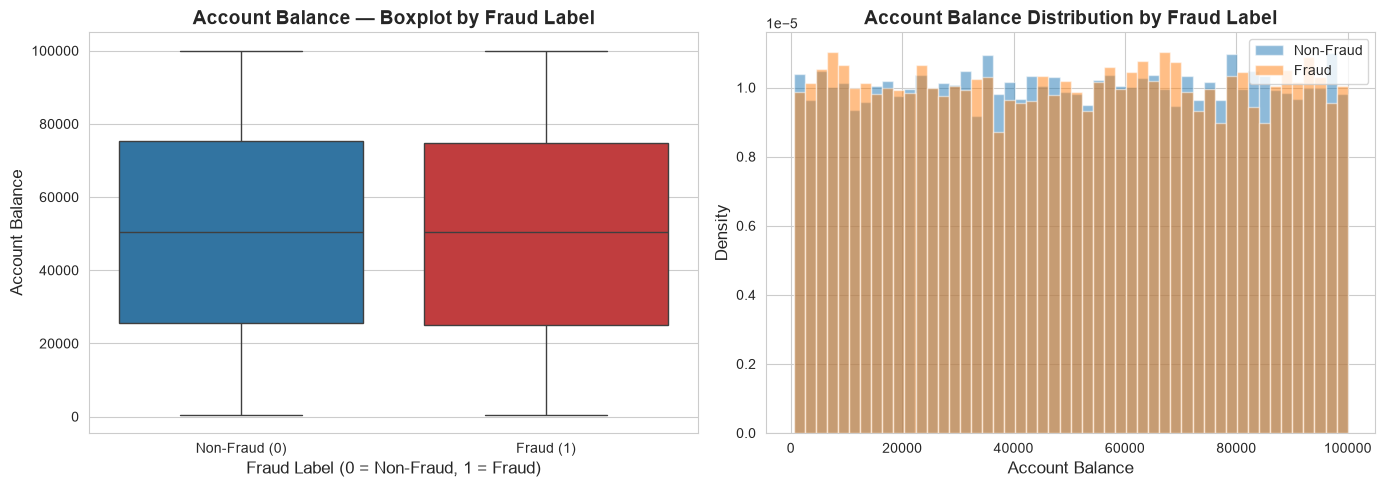


Mean account balance — Non-Fraud: $50,356.47 | Fraud: $50,162.26

Note: Account_Balance is a numerical feature, not an identifier.
No causal claims should be made from this comparison.


In [20]:
if "Account_Balance" in df.columns:
    # Summary statistics
    balance_stats = df.groupby(TARGET_COL)["Account_Balance"].describe()
    balance_stats["median"] = df.groupby(TARGET_COL)["Account_Balance"].median()
    print("Account Balance — Summary Statistics by Fraud Label")
    display(balance_stats)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot
    sns.boxplot(
        data=df, x=TARGET_COL, y="Account_Balance", ax=axes[0],
        hue=TARGET_COL, palette=[sns.color_palette()[0], sns.color_palette()[3]],
        legend=False
    )
    axes[0].set_title("Account Balance — Boxplot by Fraud Label")
    axes[0].set_xlabel("Fraud Label (0 = Non-Fraud, 1 = Fraud)")
    axes[0].set_ylabel("Account Balance")
    axes[0].set_xticklabels(["Non-Fraud (0)", "Fraud (1)"])

    # Distribution comparison
    for label, name in [(0, "Non-Fraud"), (1, "Fraud")]:
        subset = df[df[TARGET_COL] == label]["Account_Balance"]
        axes[1].hist(subset, bins=50, alpha=0.5, label=name, density=True)
    axes[1].set_title("Account Balance Distribution by Fraud Label")
    axes[1].set_xlabel("Account Balance")
    axes[1].set_ylabel("Density")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    mean_fraud_bal = df.loc[df[TARGET_COL] == 1, "Account_Balance"].mean()
    mean_nonfraud_bal = df.loc[df[TARGET_COL] == 0, "Account_Balance"].mean()
    print(f"\nMean account balance — Non-Fraud: ${mean_nonfraud_bal:,.2f} | Fraud: ${mean_fraud_bal:,.2f}")
    print("\nNote: Account_Balance is a numerical feature, not an identifier.")
    print("No causal claims should be made from this comparison.")
else:
    print("Column 'Account_Balance' not found — skipping.")

---
### 16. Card Age vs Fraud

Card Age — Summary Statistics by Fraud Label


,count,mean,std,min,25%,50%,75%,max,median
Fraud_Label,,,,,,,,,
0,33933.00,120.15,69.02,1.00,60.00,120.00,180.00,239.00,120.00
1,16067.00,119.69,68.92,1.00,60.00,119.00,179.00,239.00,119.00


C:\Users\sarva\AppData\Local\Temp\ipykernel_34468\1932854686.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Non-Fraud (0)", "Fraud (1)"])


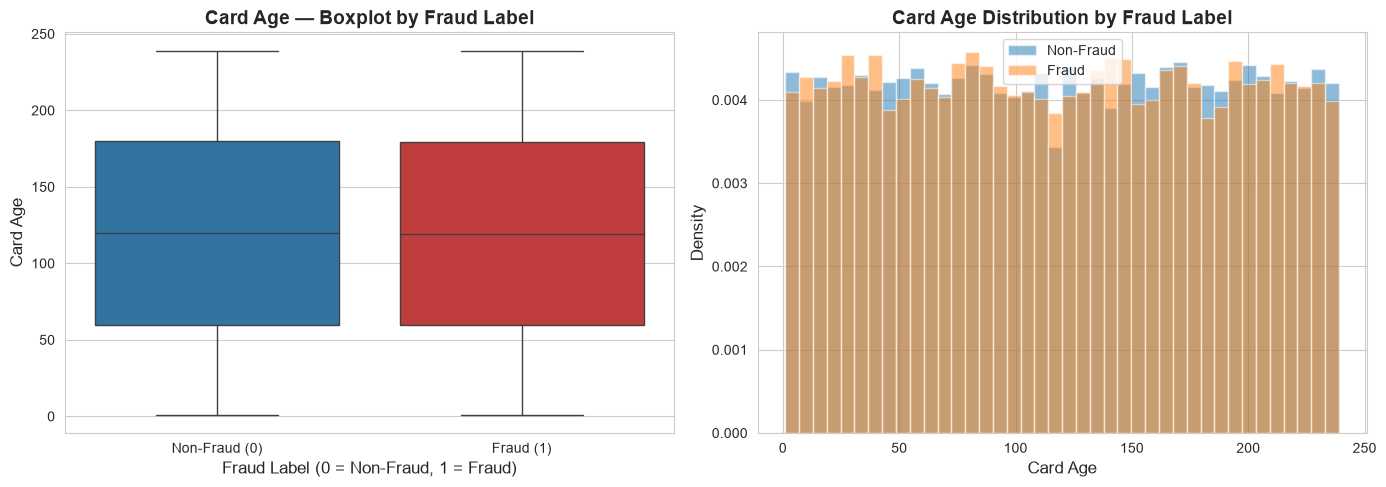


Mean card age — Non-Fraud: 120.1 | Fraud: 119.7
-> Card age distributions appear similar for fraud and non-fraud transactions.


In [21]:
if "Card_Age" in df.columns:
    # Summary statistics
    cardage_stats = df.groupby(TARGET_COL)["Card_Age"].describe()
    cardage_stats["median"] = df.groupby(TARGET_COL)["Card_Age"].median()
    print("Card Age — Summary Statistics by Fraud Label")
    display(cardage_stats)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot
    sns.boxplot(
        data=df, x=TARGET_COL, y="Card_Age", ax=axes[0],
        hue=TARGET_COL, palette=[sns.color_palette()[0], sns.color_palette()[3]],
        legend=False
    )
    axes[0].set_title("Card Age — Boxplot by Fraud Label")
    axes[0].set_xlabel("Fraud Label (0 = Non-Fraud, 1 = Fraud)")
    axes[0].set_ylabel("Card Age")
    axes[0].set_xticklabels(["Non-Fraud (0)", "Fraud (1)"])

    # Distribution comparison
    for label, name in [(0, "Non-Fraud"), (1, "Fraud")]:
        subset = df[df[TARGET_COL] == label]["Card_Age"]
        axes[1].hist(subset, bins=40, alpha=0.5, label=name, density=True)
    axes[1].set_title("Card Age Distribution by Fraud Label")
    axes[1].set_xlabel("Card Age")
    axes[1].set_ylabel("Density")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    mean_fraud_ca = df.loc[df[TARGET_COL] == 1, "Card_Age"].mean()
    mean_nonfraud_ca = df.loc[df[TARGET_COL] == 0, "Card_Age"].mean()
    print(f"\nMean card age — Non-Fraud: {mean_nonfraud_ca:.1f} | Fraud: {mean_fraud_ca:.1f}")
    if abs(mean_fraud_ca - mean_nonfraud_ca) < 5:
        print("-> Card age distributions appear similar for fraud and non-fraud transactions.")
    elif mean_fraud_ca < mean_nonfraud_ca:
        print("-> Fraudulent transactions appear associated with newer (younger) cards.")
    else:
        print("-> Fraudulent transactions appear associated with older cards.")
else:
    print("Column 'Card_Age' not found — skipping.")

---
### 17. Time-Based Fraud Patterns

Using the `Date` column for **temporary** time-based analysis only. No permanent feature-engineered columns are created.

Fraud Analysis by Month


,Total_Count,Fraud_Count,Fraud_Rate (%)
Month,,,
1,4188,1386,33.09
2,3903,1246,31.92
3,4259,1360,31.93
4,4106,1310,31.90
5,4162,1315,31.60
6,4160,1347,32.38
7,4213,1354,32.14
8,4384,1434,32.71
9,4087,1275,31.20


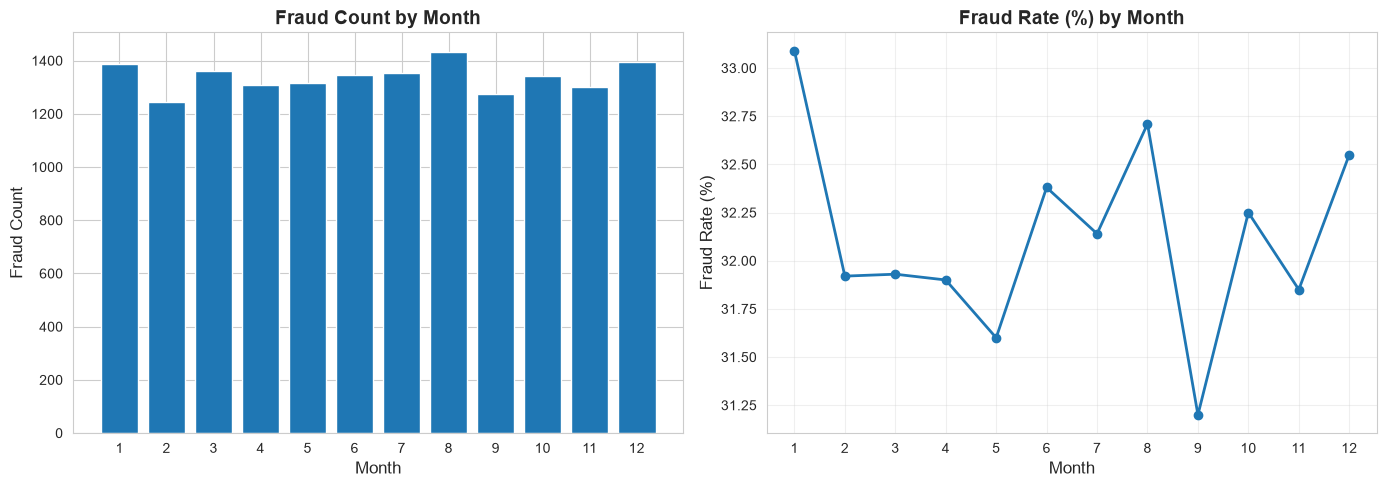


Fraud Analysis by Day of Week


,Total_Count,Fraud_Count,Fraud_Rate (%)
Day_of_Week,,,
Monday,7065,2285,32.34
Tuesday,7111,2246,31.58
Wednesday,7137,2243,31.43
Thursday,6964,2277,32.70
Friday,7240,2307,31.86
Saturday,7302,2330,31.91
Sunday,7181,2379,33.13


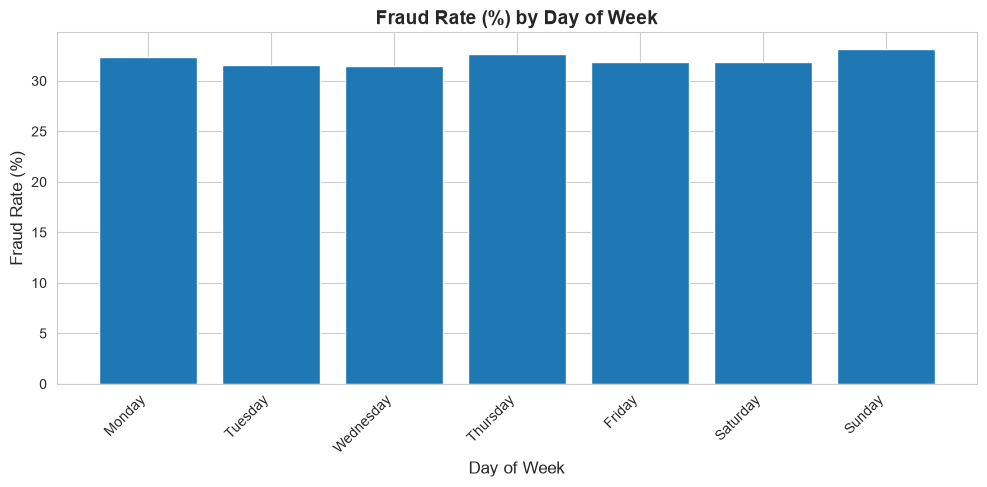


[!] These are temporary EDA analyses only. Date-based feature engineering
will be performed in Notebook 04 (Feature Engineering).


In [22]:
if "_Date_parsed" in df.columns and df["_Date_parsed"].notna().sum() > 0:
    # Temporary month and day-of-week extraction (for EDA only)
    _month = df["_Date_parsed"].dt.month
    _day_of_week = df["_Date_parsed"].dt.day_name()

    # --- Fraud rate by month ---
    monthly_analysis = df.assign(_month=_month).groupby("_month").agg(
        Total_Count=(TARGET_COL, "count"),
        Fraud_Count=(TARGET_COL, "sum")
    ).reset_index()
    monthly_analysis["Fraud_Rate (%)"] = (
        monthly_analysis["Fraud_Count"] / monthly_analysis["Total_Count"].replace(0, np.nan) * 100
    ).round(2)

    print("Fraud Analysis by Month")
    display(monthly_analysis.rename(columns={"_month": "Month"}).set_index("Month"))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Fraud count by month
    axes[0].bar(monthly_analysis["_month"], monthly_analysis["Fraud_Count"])
    axes[0].set_title("Fraud Count by Month")
    axes[0].set_xlabel("Month")
    axes[0].set_ylabel("Fraud Count")
    axes[0].set_xticks(range(1, 13))

    # Fraud rate by month
    axes[1].plot(
        monthly_analysis["_month"], monthly_analysis["Fraud_Rate (%)"],
        marker="o", linewidth=2
    )
    axes[1].set_title("Fraud Rate (%) by Month")
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel("Fraud Rate (%)")
    axes[1].set_xticks(range(1, 13))
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- Fraud rate by day of week ---
    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    dow_analysis = df.assign(_dow=_day_of_week).groupby("_dow").agg(
        Total_Count=(TARGET_COL, "count"),
        Fraud_Count=(TARGET_COL, "sum")
    ).reindex(day_order).reset_index()
    dow_analysis["Fraud_Rate (%)"] = (
        dow_analysis["Fraud_Count"] / dow_analysis["Total_Count"].replace(0, np.nan) * 100
    ).round(2)

    # Only show if there are actually multiple days
    if dow_analysis["Total_Count"].notna().sum() > 1:
        print("\nFraud Analysis by Day of Week")
        display(dow_analysis.rename(columns={"_dow": "Day_of_Week"}).set_index("Day_of_Week"))

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(dow_analysis["_dow"], dow_analysis["Fraud_Rate (%)"])
        ax.set_title("Fraud Rate (%) by Day of Week")
        ax.set_xlabel("Day of Week")
        ax.set_ylabel("Fraud Rate (%)")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    print("\n[!] These are temporary EDA analyses only. Date-based feature engineering")
    print("will be performed in Notebook 04 (Feature Engineering).")
else:
    print("Date column not available or could not be parsed — skipping time-based analysis.")

---
### 18. Correlation Analysis

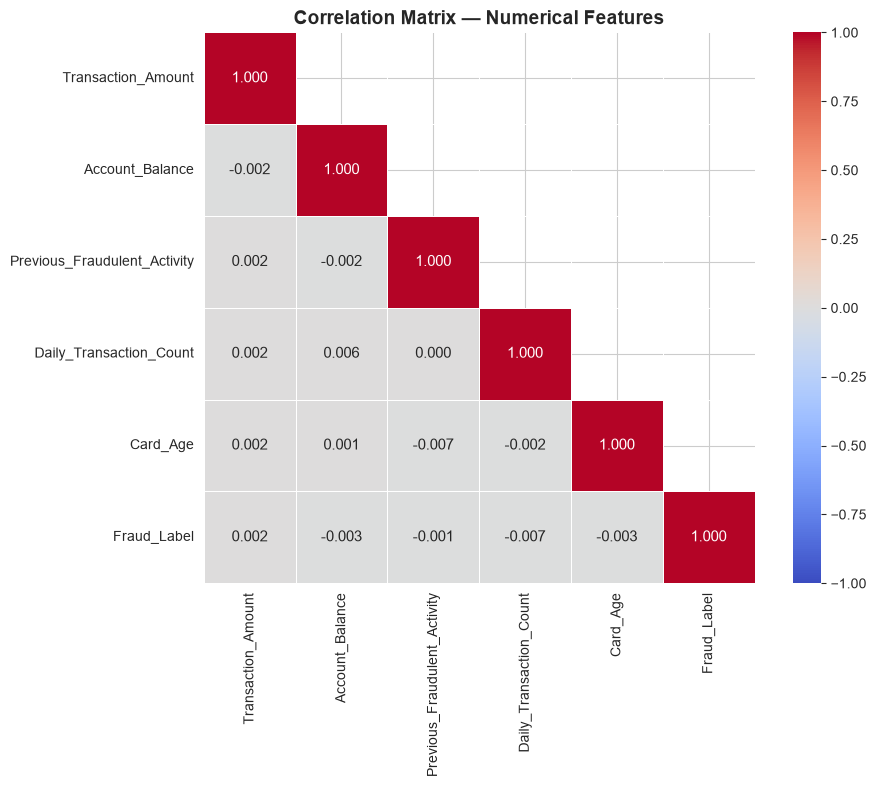


Correlation of Numerical Features with Fraud_Label:


,Correlation with Fraud_Label
Daily_Transaction_Count,-0.01
Account_Balance,-0.00
Card_Age,-0.00
Transaction_Amount,0.00
Previous_Fraudulent_Activity,-0.00



Notable correlations (|r| > 0.3):
  No feature pairs with |r| > 0.3 found.

[!] Correlation indicates association, NOT causation.
Feature selection will be addressed in later notebooks.


In [23]:
# Select relevant numerical columns for correlation (exclude identifiers and temp columns)
corr_cols = [
    c for c in numerical_cols
    if c not in ["Transaction_ID", "User_ID"] and not c.startswith("_")
]

if len(corr_cols) >= 2:
    corr_matrix = df[corr_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        mask=mask,
        ax=ax,
        vmin=-1, vmax=1
    )
    ax.set_title("Correlation Matrix — Numerical Features")
    plt.tight_layout()
    plt.show()

    # Correlations with target
    if TARGET_COL in corr_cols:
        target_corr = (
            corr_matrix[TARGET_COL]
            .drop(TARGET_COL)
            .sort_values(key=abs, ascending=False)
            .to_frame("Correlation with Fraud_Label")
        )
        print("\nCorrelation of Numerical Features with Fraud_Label:")
        display(target_corr)

    # Notable correlations (|r| > 0.3, excluding target self-correlation)
    print("\nNotable correlations (|r| > 0.3):")
    notable_found = False
    for i in range(len(corr_cols)):
        for j in range(i + 1, len(corr_cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > 0.3:
                print(f"  {corr_cols[i]} <-> {corr_cols[j]}: r = {r:.3f}")
                notable_found = True
    if not notable_found:
        print("  No feature pairs with |r| > 0.3 found.")

    print("\n[!] Correlation indicates association, NOT causation.")
    print("Feature selection will be addressed in later notebooks.")
else:
    print("Fewer than 2 numerical columns available — skipping correlation analysis.")

---
### 19. Key Fraud Patterns

This section consolidates the most important patterns observed across all preceding analyses. All findings are dynamically generated from actual computed results.

In [24]:
# Build the key patterns summary dynamically
patterns = []

# --- Transaction Type ---
if "Transaction_Type" in df.columns:
    ht = type_analysis.iloc[0]  # highest fraud rate type
    lt = type_analysis.iloc[-1]  # lowest fraud rate type
    patterns.append({
        "Feature / Dimension": "Transaction Type",
        "Observed Pattern": f"'{ht['Transaction_Type']}' has the highest fraud rate; '{lt['Transaction_Type']}' the lowest",
        "Evidence": f"{ht['Fraud_Rate (%)']:.1f}% vs {lt['Fraud_Rate (%)']:.1f}%",
        "Potential Importance": "Medium — varies by type"
    })

# --- Device Type ---
if "Device_Type" in df.columns:
    hd = device_analysis.iloc[0]
    ld = device_analysis.iloc[-1]
    spread = hd['Fraud_Rate (%)'] - ld['Fraud_Rate (%)']
    importance = "High" if spread > 5 else "Medium" if spread > 2 else "Low"
    patterns.append({
        "Feature / Dimension": "Device Type",
        "Observed Pattern": f"'{hd['Device_Type']}' shows highest fraud rate; '{ld['Device_Type']}' lowest",
        "Evidence": f"{hd['Fraud_Rate (%)']:.1f}% vs {ld['Fraud_Rate (%)']:.1f}% (spread: {spread:.1f}pp)",
        "Potential Importance": importance
    })

# --- Location ---
if "Location" in df.columns:
    hl = location_analysis.iloc[0]
    ll = location_analysis.iloc[-1]
    spread = hl['Fraud_Rate (%)'] - ll['Fraud_Rate (%)']
    importance = "High" if spread > 5 else "Medium" if spread > 2 else "Low"
    patterns.append({
        "Feature / Dimension": "Location",
        "Observed Pattern": f"'{hl['Location']}' shows highest fraud rate; '{ll['Location']}' lowest",
        "Evidence": f"{hl['Fraud_Rate (%)']:.1f}% vs {ll['Fraud_Rate (%)']:.1f}% (spread: {spread:.1f}pp)",
        "Potential Importance": importance
    })

# --- Merchant Category ---
if "Merchant_Category" in df.columns:
    hm = merchant_analysis.iloc[0]
    lm = merchant_analysis.iloc[-1]
    spread = hm['Fraud_Rate (%)'] - lm['Fraud_Rate (%)']
    importance = "High" if spread > 5 else "Medium" if spread > 2 else "Low"
    patterns.append({
        "Feature / Dimension": "Merchant Category",
        "Observed Pattern": f"'{hm['Merchant_Category']}' shows highest fraud rate; '{lm['Merchant_Category']}' lowest",
        "Evidence": f"{hm['Fraud_Rate (%)']:.1f}% vs {lm['Fraud_Rate (%)']:.1f}% (spread: {spread:.1f}pp)",
        "Potential Importance": importance
    })

# --- Transaction Amount ---
if "Transaction_Amount" in df.columns:
    diff = abs(mean_fraud - mean_nonfraud)
    direction = "higher" if mean_fraud > mean_nonfraud else "lower"
    importance = "Medium" if diff > 10 else "Low"
    patterns.append({
        "Feature / Dimension": "Transaction Amount",
        "Observed Pattern": f"Fraud transactions have {direction} average amount",
        "Evidence": f"Mean fraud: ${mean_fraud:,.2f} vs non-fraud: ${mean_nonfraud:,.2f}",
        "Potential Importance": importance
    })

# --- Previous Fraudulent Activity ---
if "Previous_Fraudulent_Activity" in df.columns and len(rate_yes) > 0 and len(rate_no) > 0:
    diff = rate_yes[0] - rate_no[0]
    importance = "High" if abs(diff) > 10 else "Medium" if abs(diff) > 3 else "Low"
    direction = "higher" if diff > 0 else "lower"
    patterns.append({
        "Feature / Dimension": "Previous Fraudulent Activity",
        "Observed Pattern": f"Users with prior fraud history show {direction} current fraud rate",
        "Evidence": f"Prior fraud: {rate_yes[0]:.1f}% vs no prior: {rate_no[0]:.1f}% (diff: {abs(diff):.1f}pp)",
        "Potential Importance": importance
    })

# --- Daily Transaction Count ---
if "Daily_Transaction_Count" in df.columns:
    diff = mean_fraud_dtc - mean_nonfraud_dtc
    direction = "higher" if diff > 0 else "lower"
    importance = "Medium" if abs(diff) > 1 else "Low"
    patterns.append({
        "Feature / Dimension": "Daily Transaction Count",
        "Observed Pattern": f"Fraud transactions associated with {direction} daily counts",
        "Evidence": f"Mean fraud: {mean_fraud_dtc:.1f} vs non-fraud: {mean_nonfraud_dtc:.1f}",
        "Potential Importance": importance
    })

# --- Card Age ---
if "Card_Age" in df.columns:
    diff = mean_fraud_ca - mean_nonfraud_ca
    if abs(diff) < 5:
        direction = "similar"
    elif diff < 0:
        direction = "newer (younger) cards"
    else:
        direction = "older cards"
    importance = "Medium" if abs(diff) > 10 else "Low"
    patterns.append({
        "Feature / Dimension": "Card Age",
        "Observed Pattern": f"Fraud associated with {direction}",
        "Evidence": f"Mean fraud: {mean_fraud_ca:.1f} vs non-fraud: {mean_nonfraud_ca:.1f}",
        "Potential Importance": importance
    })

# Display the summary table
if patterns:
    patterns_df = pd.DataFrame(patterns)
    print("=" * 80)
    print("KEY FRAUD PATTERNS SUMMARY")
    print("=" * 80)
    display(patterns_df.set_index("Feature / Dimension"))
else:
    print("No patterns could be computed — check that expected columns are present.")

KEY FRAUD PATTERNS SUMMARY


,Observed Pattern,Evidence,Potential Importance
Feature / Dimension,,,
Transaction Type,'ATM Withdrawal' has the highest fraud rate; '...,32.5% vs 31.8%,Medium — varies by type
Device Type,'Tablet' shows highest fraud rate; 'Mobile' lo...,32.6% vs 31.9% (spread: 0.7pp),Low
Location,'New York' shows highest fraud rate; 'Mumbai' ...,32.5% vs 31.6% (spread: 0.9pp),Low
Merchant Category,'Restaurants' shows highest fraud rate; 'Cloth...,32.6% vs 31.7% (spread: 0.9pp),Low
Transaction Amount,Fraud transactions have higher average amount,Mean fraud: $99.68 vs non-fraud: $99.28,Low
Previous Fraudulent Activity,Users with prior fraud history show lower curr...,Prior fraud: 32.0% vs no prior: 32.1% (diff: 0...,Low
Daily Transaction Count,Fraud transactions associated with lower daily...,Mean fraud: 7.4 vs non-fraud: 7.5,Low
Card Age,Fraud associated with similar,Mean fraud: 119.7 vs non-fraud: 120.1,Low


---
### 20. Business Insights

The following insights are derived from the observed patterns in this synthetic dataset. They represent **associations**, not causal relationships.

In [25]:
print("=" * 70)
print("BUSINESS INSIGHTS FROM EDA")
print("=" * 70)

insights = []

# Transaction Type insight
if "Transaction_Type" in df.columns:
    ht = type_analysis.iloc[0]
    lt = type_analysis.iloc[-1]
    insights.append(
        f"Transactions of type '{ht['Transaction_Type']}' showed a higher observed fraud rate "
        f"({ht['Fraud_Rate (%)']:.1f}%) compared to '{lt['Transaction_Type']}' ({lt['Fraud_Rate (%)']:.1f}%)."
    )

# Device Type insight
if "Device_Type" in df.columns:
    hd = device_analysis.iloc[0]
    insights.append(
        f"Transactions on '{hd['Device_Type']}' devices showed the highest observed fraud rate "
        f"({hd['Fraud_Rate (%)']:.1f}%), which may warrant additional monitoring for this channel."
    )

# Location insight
if "Location" in df.columns:
    hl = location_analysis.iloc[0]
    insights.append(
        f"Among the {n_locations} locations, '{hl['Location']}' showed the highest observed fraud rate "
        f"({hl['Fraud_Rate (%)']:.1f}%), suggesting location-specific monitoring may be beneficial."
    )

# Merchant Category insight
if "Merchant_Category" in df.columns:
    hm = merchant_analysis.iloc[0]
    insights.append(
        f"Certain merchant categories, particularly '{hm['Merchant_Category']}', showed "
        f"elevated observed fraud rates ({hm['Fraud_Rate (%)']:.1f}%)."
    )

# Previous Fraudulent Activity insight
if "Previous_Fraudulent_Activity" in df.columns and len(rate_yes) > 0 and len(rate_no) > 0:
    if rate_yes[0] > rate_no[0]:
        insights.append(
            f"Transactions with previous fraudulent activity showed a higher observed fraud rate "
            f"({rate_yes[0]:.1f}%) compared to those without ({rate_no[0]:.1f}%). "
            f"This appears to be a meaningful behavioral signal."
        )
    else:
        insights.append(
            f"Previous fraudulent activity showed a fraud rate of {rate_yes[0]:.1f}% "
            f"vs {rate_no[0]:.1f}% without prior history."
        )

# Transaction Amount insight
if "Transaction_Amount" in df.columns:
    direction = "higher" if mean_fraud > mean_nonfraud else "lower"
    insights.append(
        f"Fraudulent transactions had a {direction} average amount "
        f"(${mean_fraud:,.2f}) compared to non-fraudulent transactions (${mean_nonfraud:,.2f}), "
        f"though distributions overlap considerably."
    )

# Dataset limitation
insights.append(
    f"\n[!] DATASET LIMITATION: The fraud rate of ~{fraud_percentage:.1f}% in this synthetic dataset "
    f"is significantly higher than real-world fraud rates (typically < 1%). All patterns "
    f"should be validated on real data before deploying in production."
)

for i, insight in enumerate(insights, 1):
    print(f"\n{i}. {insight}")

print("\n" + "-" * 70)
print("All insights above are observational. No causal claims are made.")

BUSINESS INSIGHTS FROM EDA

1. Transactions of type 'ATM Withdrawal' showed a higher observed fraud rate (32.5%) compared to 'POS' (31.8%).

2. Transactions on 'Tablet' devices showed the highest observed fraud rate (32.6%), which may warrant additional monitoring for this channel.

3. Among the 5 locations, 'New York' showed the highest observed fraud rate (32.5%), suggesting location-specific monitoring may be beneficial.

4. Certain merchant categories, particularly 'Restaurants', showed elevated observed fraud rates (32.6%).

5. Previous fraudulent activity showed a fraud rate of 32.0% vs 32.1% without prior history.

6. Fraudulent transactions had a higher average amount ($99.68) compared to non-fraudulent transactions ($99.28), though distributions overlap considerably.

7. 
[!] DATASET LIMITATION: The fraud rate of ~32.1% in this synthetic dataset is significantly higher than real-world fraud rates (typically < 1%). All patterns should be validated on real data before deploying 

---
### 21. Implications for Feature Engineering

Based on the EDA findings above, the following are **potential features** to explore in Notebook 04. None are implemented here.

---

#### POTENTIAL FEATURES FOR NOTEBOOK 04

In [26]:
print("=" * 70)
print("POTENTIAL FEATURES FOR NOTEBOOK 04 (Feature Engineering)")
print("=" * 70)

potential_features = []

# Transaction Amount transformations
if "Transaction_Amount" in df.columns:
    skewness = df["Transaction_Amount"].skew()
    if abs(skewness) > 0.5:
        potential_features.append(
            "Transaction Amount transformations (e.g., log transform) — "
            f"current skewness: {skewness:.2f}"
        )
    potential_features.append(
        "Transaction amount bins/categories (small, medium, large, very large)"
    )

# Temporal features
if "Date" in df.columns:
    potential_features.append(
        "Temporal features from Date: month, day of week, day of month, "
        "weekend flag, quarter"
    )

# Customer behavioral aggregations
if "User_ID" in df.columns:
    potential_features.append(
        "Customer behavioral aggregations using User_ID: "
        "average transaction amount per user, transaction frequency per user, "
        "number of distinct merchants per user"
    )

# Transaction frequency
if "Daily_Transaction_Count" in df.columns:
    potential_features.append(
        "Daily transaction count bins or flags for unusually high counts"
    )

# Previous fraud indicators
if "Previous_Fraudulent_Activity" in df.columns:
    potential_features.append(
        "Previous fraud indicator — already binary, consider interaction "
        "features with other variables"
    )

# Categorical encoding
cat_to_encode = [
    c for c in ["Transaction_Type", "Device_Type", "Location",
                "Merchant_Category", "Card_Type"]
    if c in df.columns
]
if cat_to_encode:
    potential_features.append(
        f"Categorical encoding for: {', '.join(cat_to_encode)} "
        f"(one-hot, label, or target encoding)"
    )

# Card age
if "Card_Age" in df.columns:
    potential_features.append(
        "Card age bins (new, moderate, established) based on distribution"
    )

# Interaction features
potential_features.append(
    "Interaction features: e.g., Transaction_Amount × Daily_Transaction_Count, "
    "Device_Type × Location combinations"
)

for i, feature in enumerate(potential_features, 1):
    print(f"  {i}. {feature}")

print("\n[!] These are IDEAS only. Implementation will be in Notebook 04.")
print("Final feature decisions will depend on model performance and validation.")

POTENTIAL FEATURES FOR NOTEBOOK 04 (Feature Engineering)
  1. Transaction Amount transformations (e.g., log transform) — current skewness: 2.00
  2. Transaction amount bins/categories (small, medium, large, very large)
  3. Temporal features from Date: month, day of week, day of month, weekend flag, quarter
  4. Customer behavioral aggregations using User_ID: average transaction amount per user, transaction frequency per user, number of distinct merchants per user
  5. Daily transaction count bins or flags for unusually high counts
  6. Previous fraud indicator — already binary, consider interaction features with other variables
  7. Categorical encoding for: Transaction_Type, Device_Type, Location, Merchant_Category, Card_Type (one-hot, label, or target encoding)
  8. Card age bins (new, moderate, established) based on distribution
  9. Interaction features: e.g., Transaction_Amount × Daily_Transaction_Count, Device_Type × Location combinations

[!] These are IDEAS only. Implementatio

---
### 22. EDA Summary & Next Notebook

In [27]:
# Clean up temporary columns before summary
temp_cols = [c for c in df.columns if c.startswith("_")]
if temp_cols:
    df.drop(columns=temp_cols, inplace=True)
    print(f"Cleaned up {len(temp_cols)} temporary column(s): {temp_cols}")

print("\n" + "=" * 70)
print("EDA SUMMARY")
print("=" * 70)

print("\n1. MOST IMPORTANT FRAUD PATTERNS:")
if patterns:
    high_importance = [p for p in patterns if p["Potential Importance"] == "High"]
    medium_importance = [p for p in patterns if p["Potential Importance"] == "Medium"]
    if high_importance:
        print("   High importance:")
        for p in high_importance:
            print(f"     • {p['Feature / Dimension']}: {p['Observed Pattern']}")
    if medium_importance:
        print("   Medium importance:")
        for p in medium_importance:
            print(f"     • {p['Feature / Dimension']}: {p['Observed Pattern']}")

print("\n2. IMPORTANT NUMERICAL OBSERVATIONS:")
if "Transaction_Amount" in df.columns:
    print(f"   • Transaction Amount: Mean fraud=${mean_fraud:,.2f} vs non-fraud=${mean_nonfraud:,.2f}")
if "Account_Balance" in df.columns:
    print(f"   • Account Balance: Mean fraud=${mean_fraud_bal:,.2f} vs non-fraud=${mean_nonfraud_bal:,.2f}")
if "Daily_Transaction_Count" in df.columns:
    print(f"   • Daily Transaction Count: Mean fraud={mean_fraud_dtc:.1f} vs non-fraud={mean_nonfraud_dtc:.1f}")
if "Card_Age" in df.columns:
    print(f"   • Card Age: Mean fraud={mean_fraud_ca:.1f} vs non-fraud={mean_nonfraud_ca:.1f}")

print("\n3. IMPORTANT CATEGORICAL OBSERVATIONS:")
if "Transaction_Type" in df.columns:
    print(f"   • Transaction Type: Fraud rates range from {type_analysis['Fraud_Rate (%)'].min():.1f}% to {type_analysis['Fraud_Rate (%)'].max():.1f}%")
if "Device_Type" in df.columns:
    print(f"   • Device Type: Fraud rates range from {device_analysis['Fraud_Rate (%)'].min():.1f}% to {device_analysis['Fraud_Rate (%)'].max():.1f}%")
if "Location" in df.columns:
    print(f"   • Location: Fraud rates range from {location_analysis['Fraud_Rate (%)'].min():.1f}% to {location_analysis['Fraud_Rate (%)'].max():.1f}%")
if "Merchant_Category" in df.columns:
    print(f"   • Merchant Category: Fraud rates range from {merchant_analysis['Fraud_Rate (%)'].min():.1f}% to {merchant_analysis['Fraud_Rate (%)'].max():.1f}%")
if "Card_Type" in df.columns:
    print(f"   • Card Type: Fraud rates range from {card_analysis['Fraud_Rate (%)'].min():.1f}% to {card_analysis['Fraud_Rate (%)'].max():.1f}%")

print("\n4. BEHAVIORAL OBSERVATIONS:")
if "Previous_Fraudulent_Activity" in df.columns:
    if len(rate_yes) > 0 and len(rate_no) > 0:
        print(f"   • Previous fraud history: {rate_yes[0]:.1f}% vs {rate_no[0]:.1f}% fraud rate")

print("\n5. DATASET LIMITATIONS:")
print(f"   • Synthetic dataset with ~{fraud_percentage:.1f}% fraud rate (unrealistic for production)")
print("   • Real-world fraud rates are typically well below 1%")
print("   • All observed patterns reflect this synthetic data and require validation")
print("   • Correlation does not imply causation")

print("\n6. POTENTIAL FEATURE ENGINEERING DIRECTIONS:")
print("   • Transaction amount transformations and bins")
print("   • Temporal features from Date column")
print("   • Customer behavioral aggregations using User_ID")
print("   • Categorical encoding strategies")
print("   • Interaction features between key dimensions")

print("\n" + "=" * 70)
print("Notebook 03 completed: Exploratory Data Analysis.")
print("\nNext notebook: 04_feature_engineering.ipynb")
print("=" * 70)

Cleaned up 1 temporary column(s): ['_Date_parsed']

EDA SUMMARY

1. MOST IMPORTANT FRAUD PATTERNS:

2. IMPORTANT NUMERICAL OBSERVATIONS:
   • Transaction Amount: Mean fraud=$99.68 vs non-fraud=$99.28
   • Account Balance: Mean fraud=$50,162.26 vs non-fraud=$50,356.47
   • Daily Transaction Count: Mean fraud=7.4 vs non-fraud=7.5
   • Card Age: Mean fraud=119.7 vs non-fraud=120.1

3. IMPORTANT CATEGORICAL OBSERVATIONS:
   • Transaction Type: Fraud rates range from 31.8% to 32.5%
   • Device Type: Fraud rates range from 31.9% to 32.6%
   • Location: Fraud rates range from 31.6% to 32.5%
   • Merchant Category: Fraud rates range from 31.7% to 32.6%
   • Card Type: Fraud rates range from 31.8% to 32.5%

4. BEHAVIORAL OBSERVATIONS:
   • Previous fraud history: 32.0% vs 32.1% fraud rate

5. DATASET LIMITATIONS:
   • Synthetic dataset with ~32.1% fraud rate (unrealistic for production)
   • Real-world fraud rates are typically well below 1%
   • All observed patterns reflect this synthetic dat